## Metin Görselleştirme

In [1]:
import pandas as pd
data = pd.read_csv("train.tsv", sep = "\t")

In [2]:
data.head()

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,A series of escapades demonstrating the adage ...,1
1,2,1,A series of escapades demonstrating the adage ...,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156060 entries, 0 to 156059
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   PhraseId    156060 non-null  int64 
 1   SentenceId  156060 non-null  int64 
 2   Phrase      156060 non-null  object
 3   Sentiment   156060 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 4.8+ MB


In [4]:
#buyuk-kucuk harf donusumu
data["Phrase"] = data["Phrase"].apply(lambda x: " ".join(x.lower() for x in x.split()))

In [5]:
#noktalama isaretleri
data["Phrase"] = data["Phrase"].str.replace("[^\\w\\s]", " ")

In [6]:
#sayilar
data["Phrase"] = data["Phrase"].str.replace("\\d", " ")

In [7]:
#stopwords
import nltk
from nltk.corpus import stopwords
sw = stopwords.words("english")
data["Phrase"] = data["Phrase"].apply(lambda x: " ".join(x for x in x.split() if x not in sw))

In [8]:
#seyreklerin silinmesi
delete = pd.Series(" ".join(data["Phrase"]).split()).value_counts()[-1000:]
data["Phrase"] = data["Phrase"].apply(lambda x: " ".join(x for x in x.split() if x not in delete))

In [9]:
#lemmatization
from textblob import Word
data["Phrase"] = data["Phrase"].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()])
)

In [10]:
data["Phrase"].head(10)

0    series escapade demonstrating adage good goose...
1       series escapade demonstrating adage good goose
2                                               series
3                                                     
4                                               series
5              escapade demonstrating adage good goose
6                                                     
7              escapade demonstrating adage good goose
8                                             escapade
9                       demonstrating adage good goose
Name: Phrase, dtype: object

### Terim Frekansı

In [11]:
from collections import Counter
import pandas as pd

counter = Counter(
    " ".join(data["Phrase"].dropna()).split()
)

tf1 = pd.DataFrame(
    counter.items(),
    columns=["word", "count"]
).sort_values("count", ascending=False)

In [12]:
tf1.head()

,word,count
8,",",42006
15,.,17565
26,'s,16971
205,film,7668
133,movie,7250


In [13]:
tf1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14165 entries, 8 to 14059
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   word    14165 non-null  object
 1   count   14165 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 332.0+ KB


In [14]:
tf1.nunique()

word     14165
count      525
dtype: int64

In [15]:
a = tf1[tf1["count"] > 5000]

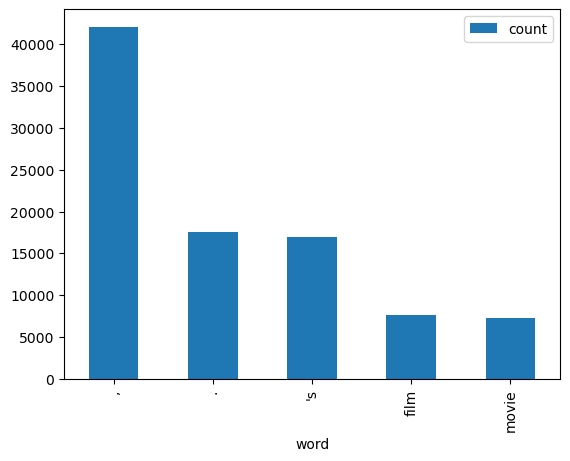

In [16]:
a.plot.bar(x = "word", y = "count");

### WordCloud

In [17]:
import numpy as np
import pandas as pd
from os import path
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

In [18]:
text = data["Phrase"][0]

In [19]:
wordcloud = WordCloud().generate(text)

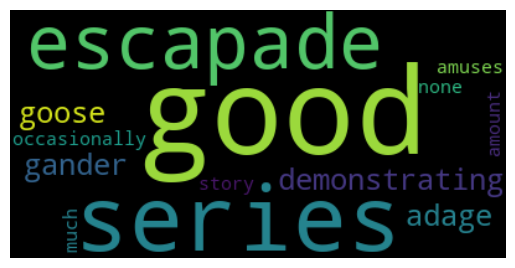

In [20]:
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

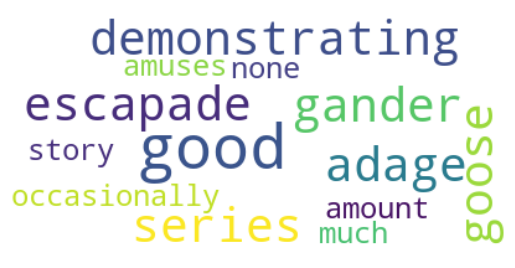

In [21]:
wordcloud = WordCloud(max_font_size = 50,
                      max_words = 100,
                      background_color = "white").generate(text)

plt.figure()
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

In [22]:
wordcloud.to_file("word_cloud.png");

In [23]:
#tum metin

In [24]:
text = " ".join(i for i in data.Phrase)

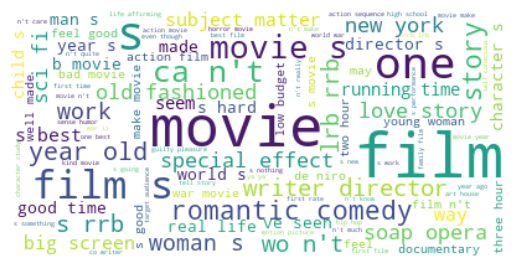

In [25]:
wordcloud = WordCloud(max_font_size = 50,
                      max_words = 100,
                      background_color = "white").generate(text)

plt.figure()
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")
plt.show()

### Şablonlara Göre Word Cloud

In [26]:
hl_mask = np.array(Image.open("hl3.jpg"))

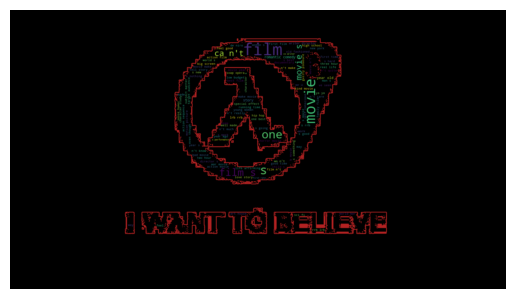

In [27]:
wc = WordCloud(max_words = 100,
                      mask = hl_mask,
                      contour_width = 3,
                      contour_color = "firebrick")
wc.generate(text)
wc.to_file("HL3.png")

plt.figure()
plt.imshow(wc, interpolation = "bilinear")
plt.axis("off")
plt.show()